In [1]:
pip install -r requirements.txt

  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.49-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
Using cached sqlalchemy-2.0.49-cp313-cp313-macosx_11_0_arm64.whl (2.2 MB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)
Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl (173 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]2m5/6 [optuna]

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to us

# # Предсказание цен на недвижимость - Проект

## Импорт библиотек

**Что делает:** Загружает все необходимые библиотеки для анализа данных и построения моделей.

**Основные группы:**
- **Работа с данными** — pandas, numpy
- **Визуализация** — matplotlib, seaborn
- **Предобработка** — sklearn (StandardScaler, OneHotEncoder, Pipeline)
- **Модели** — RandomForest, Ridge, Lasso, XGBoost
- **Метрики** — RMSE, MAE, R²
- **Валидация** — cross_val_score, KFold

**Результат:** Подготовлено окружение для полного цикла ML-проекта

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
import xgboost as xgb

import optuna
from optuna.samplers import TPESampler

## Загрузка данных

**Что делает:** Загружает три основных файла соревнования.

**Файлы:**
- `train.csv` — обучающая выборка с целевой переменной SalePrice
- `test.csv` — тестовая выборка без целевой переменной
- `sample_submission.csv` — шаблон для отправки результатов

**Результат:**
- Train shape: (1460, 81) — 1460 домов, 80 признаков + таргет
- Test shape: (1459, 80) — 1459 домов для предсказания

In [3]:
# Загрузка данных
train = pd.read_csv('./assets/train.csv')
test = pd.read_csv('./assets/test.csv')
submission = pd.read_csv('./assets/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Target column: SalePrice")

Train shape: (1460, 81)
Test shape: (1459, 80)
Target column: SalePrice


## Анализ распределения целевой переменной

**Что делает:** Визуализирует распределение цен на недвижимость до и после логарифмирования.

**Ключевые наблюдения:**
- Оригинальный SalePrice имеет **высокую положительную асимметрию** (скьюс > 1)
- Логарифмирование нормализует распределение, приближая его к нормальному

**Результат:**
- Skewness original: ~1.88 (сильно смещено вправо)
- Skewness log: ~0.12 (близко к нормальному)

**Вывод:** Модель будем обучать на логарифмированном таргете — это повысит качество предсказаний. Берём логарифм цены — это "сжимает" дорогие дома ближе к дешёвым.

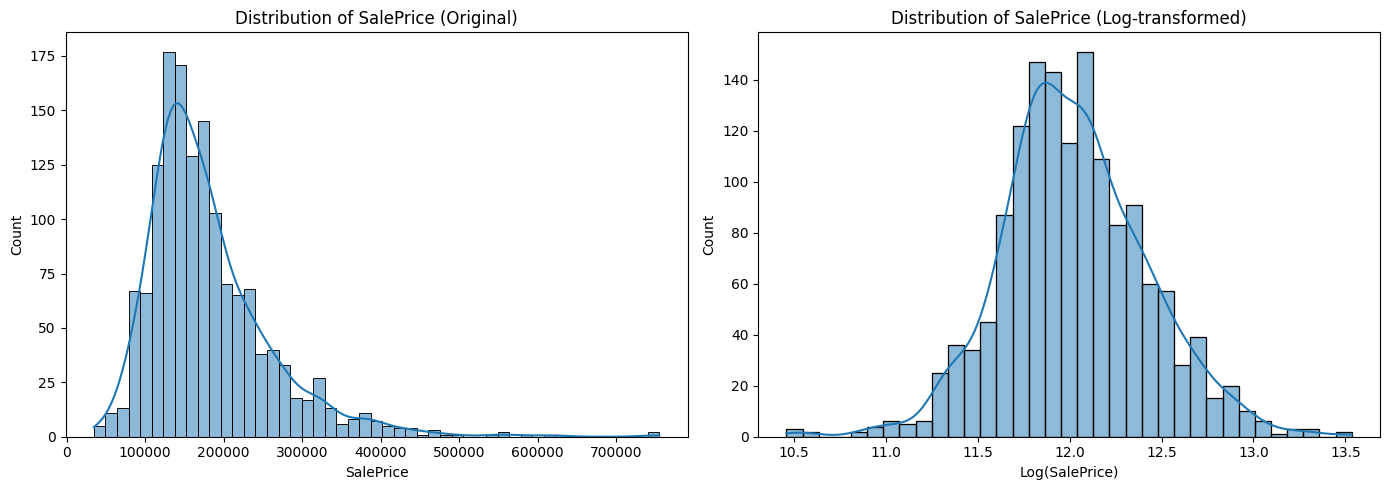

Skewness original: 1.88
Skewness log: 0.12


In [4]:
# 1. Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Оригинальный таргет
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of SalePrice (Original)')
axes[0].set_xlabel('SalePrice')

# Логарифмированный таргет
train['LogSalePrice'] = np.log1p(train['SalePrice'])
sns.histplot(train['LogSalePrice'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of SalePrice (Log-transformed)')
axes[1].set_xlabel('Log(SalePrice)')

plt.tight_layout()
plt.show()

print(f"Skewness original: {train['SalePrice'].skew():.2f}")
print(f"Skewness log: {train['LogSalePrice'].skew():.2f}")

## Визуальный анализ признаков

**Что делает:** Исследует распределение числовых и категориальных признаков, а также их связь с ценой.

###  Числовые признаки (25 графиков)
- Гистограммы показывают распределение каждой числовой переменной
- Помогают обнаружить выбросы и асимметрию

###  Категориальные признаки (16 графиков)
- Топ-10 самых частых категорий для каждого признака
- Показывает популярность типов домов, материалов, районов и т.д.

### 3. Корреляция с SalePrice
**Топ-5 наиболее влияющих признаков:**
- `OverallQual` — общее качество (сильнее всего влияет)
- `GrLivArea` — жилая площадь
- `TotalBsmtSF` — площадь подвала
- `GarageCars` — вместимость гаража
- `GarageArea` — площадь гаража

**Результат:** Понимаем, какие признаки важны для предсказания цены.

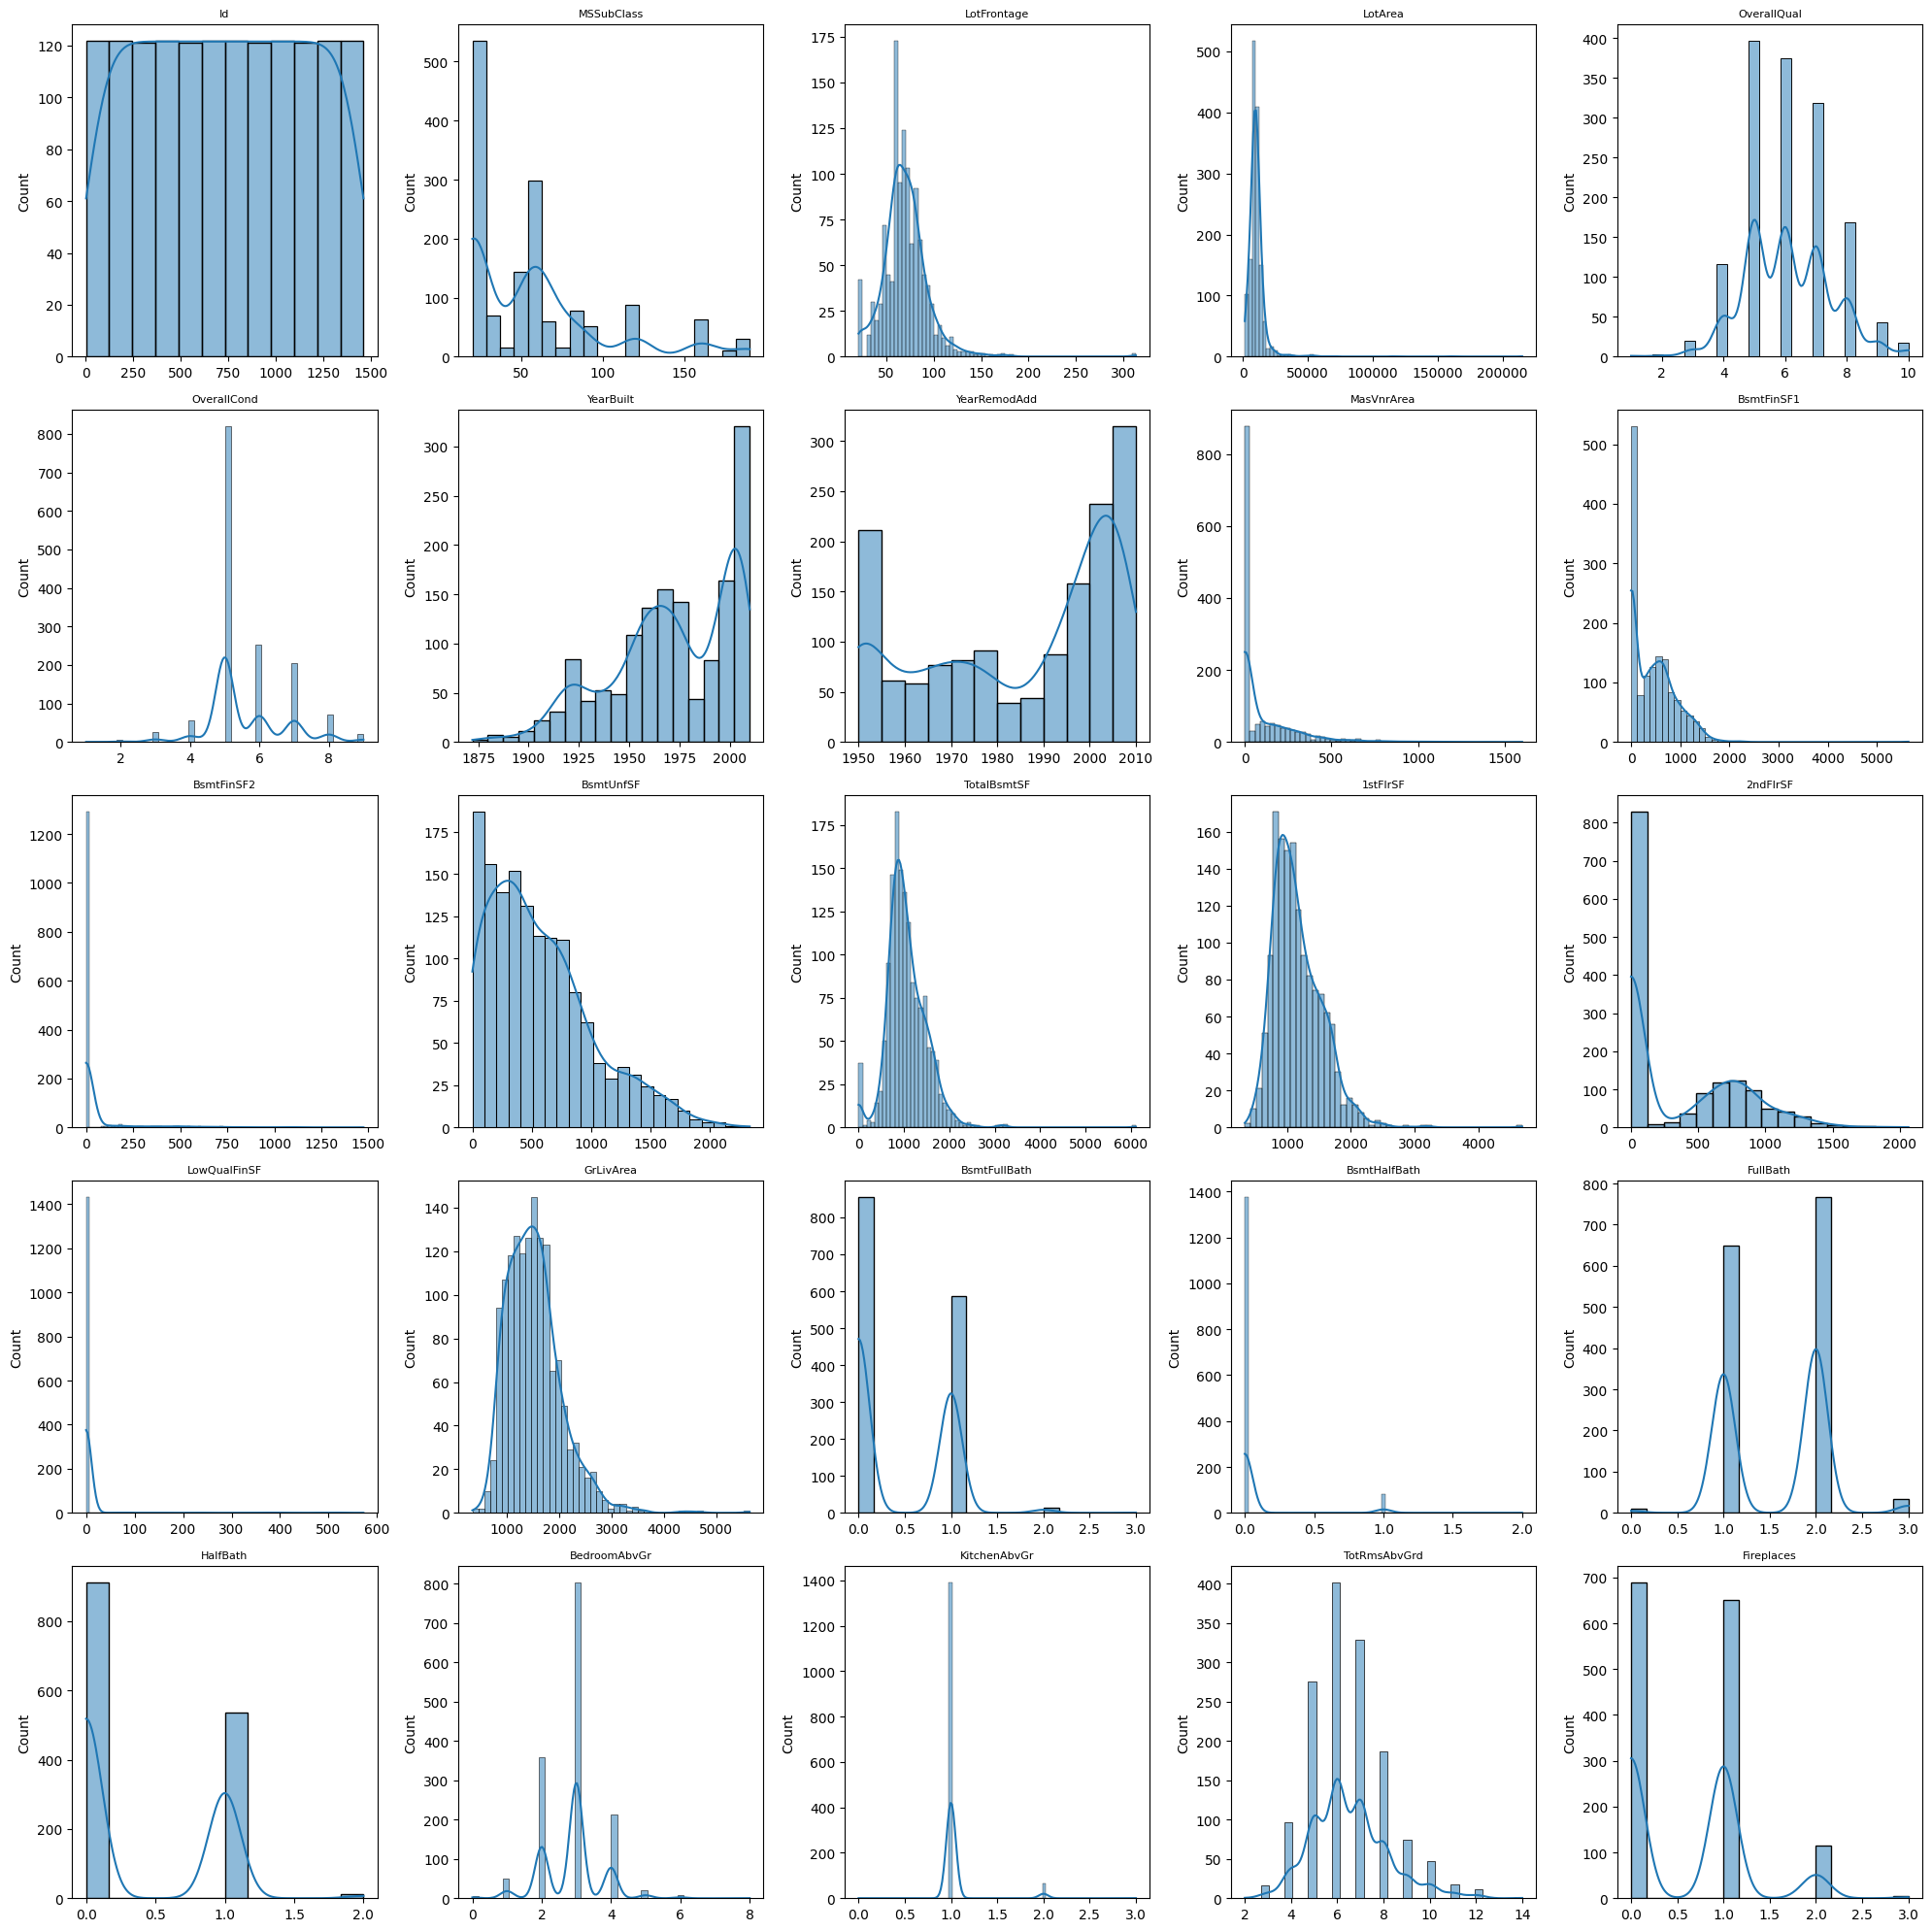

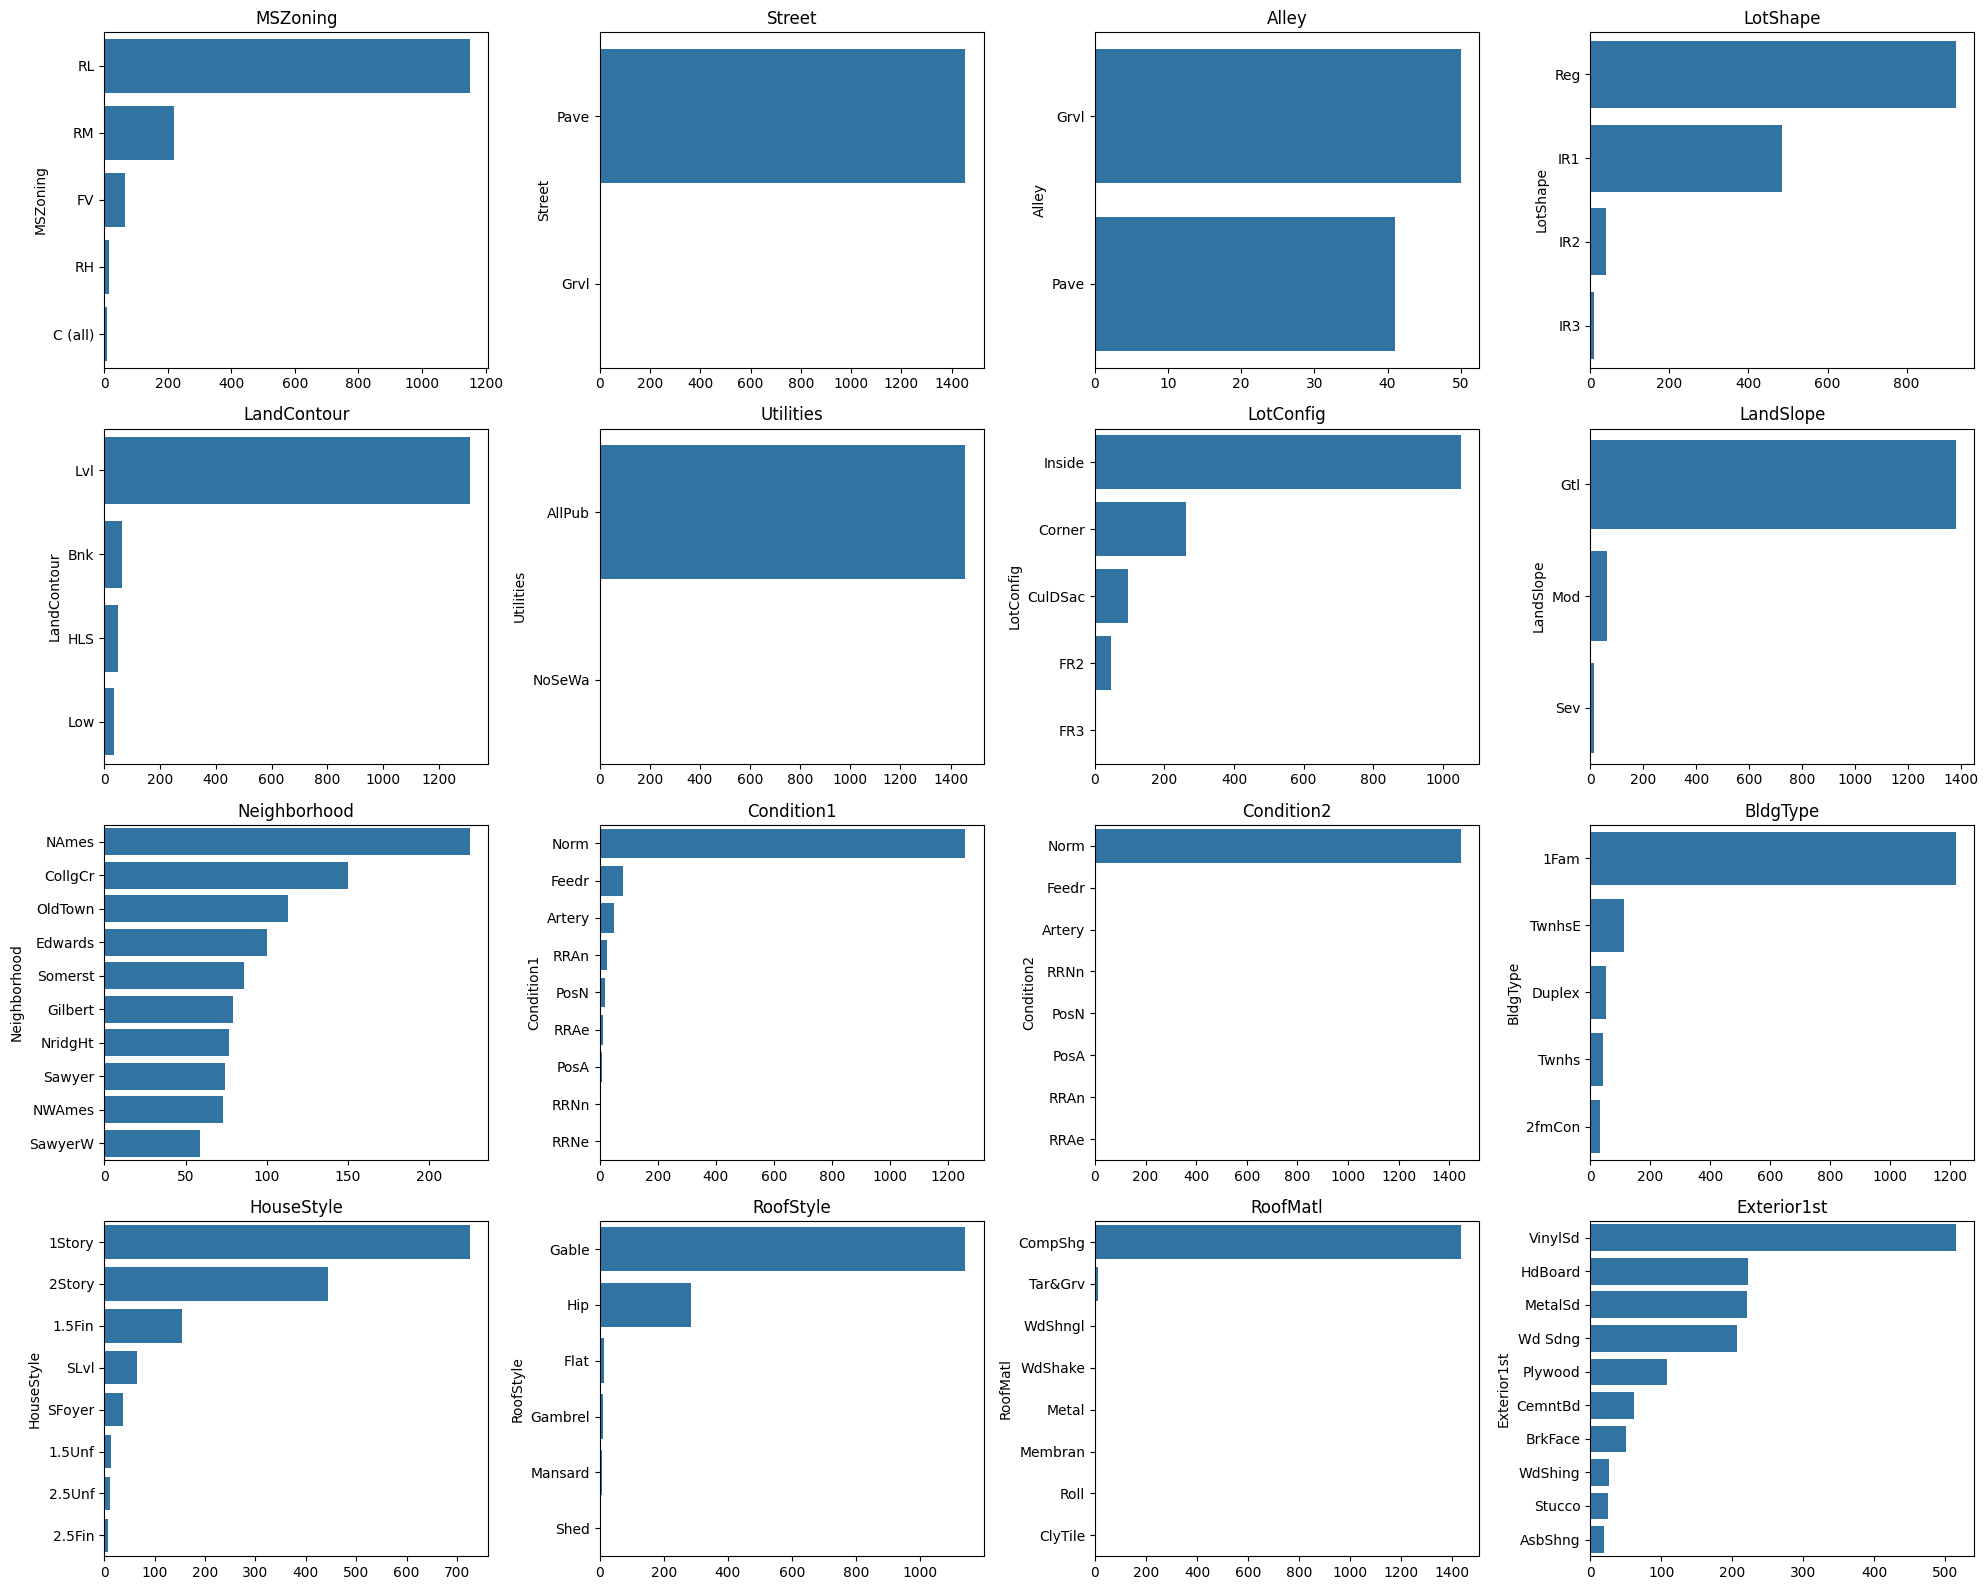

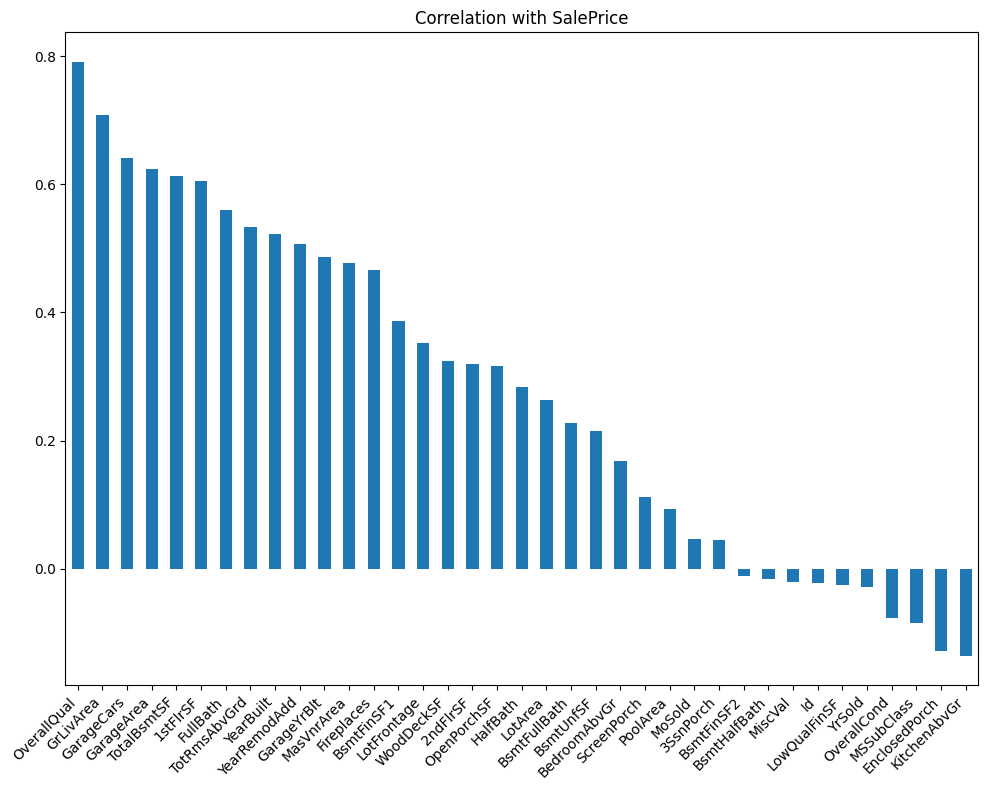

In [5]:
# 2. Числовые признаки
numeric_cols = train.select_dtypes(include=[np.number]).columns.drop(['SalePrice', 'LogSalePrice'])
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:25]):
    sns.histplot(train[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# %% [code]
# 3. Категориальные признаки
categorical_cols = train.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:16]):
    top_categories = train[col].value_counts().head(10)
    sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# %% [code]
# 4. Матрица корреляций с таргетом
correlations = train[numeric_cols.tolist() + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
correlations.drop('SalePrice').plot(kind='bar')
plt.title('Correlation with SalePrice')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Объединение данных и анализ пропусков

**Что делает:** Объединяет train и test для единой предобработки, затем визуализирует пропуски.

### Объединение данных
- Сохраняем таргет отдельно (`SalePrice` и его логарифм)
- Добавляем метку `is_train` (1 — обучение, 0 — тест)
- Объединяем для одинаковой обработки признаков

**Результат:** `all_data.shape` — (2919, 80+ признаков)

### Анализ пропусков
- Строит барплот колонок с пропущенными значениями
- Выводит список колонок и количество NaN

**Типичные колонки с пропусками:**
- `LotFrontage` — фронтальная линия участка (~486 пропусков)
- `GarageYrBlt` — год постройки гаража (~159)
- Категориальные: Alley, PoolQC, Fence, FireplaceQu и др.

**Вывод:** Много пропусков — нужно продумать стратегию заполнения.

All data shape: (2919, 81)


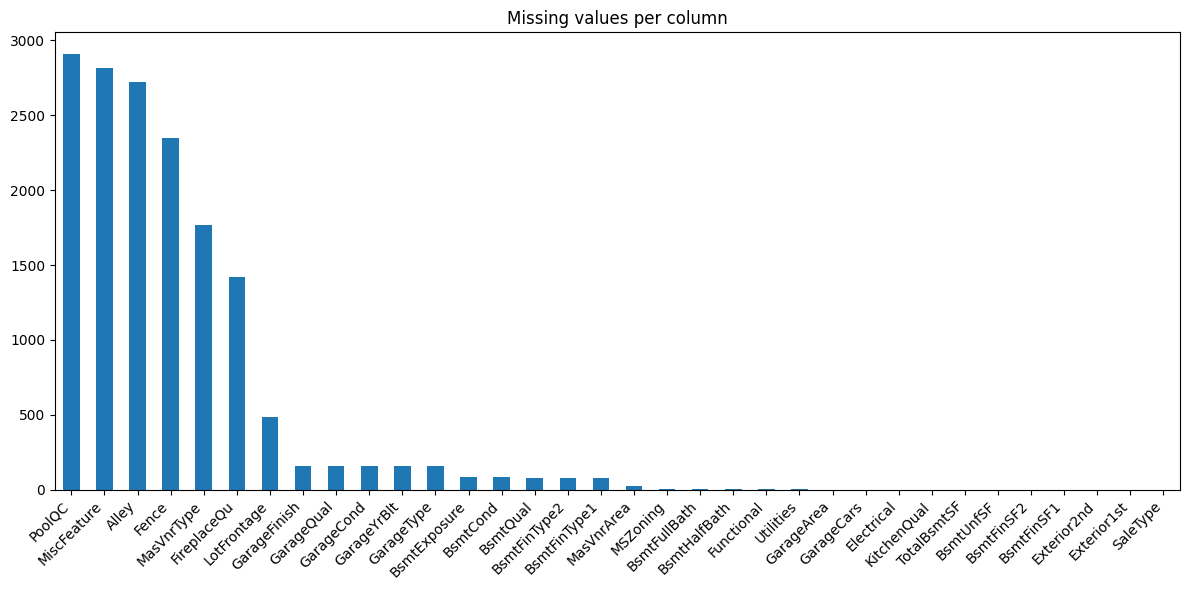


Columns with missing values:
PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageFinish     159
GarageQual       159
GarageCond       159
GarageYrBlt      159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
BsmtHalfBath       2
Functional         2
Utilities          2
GarageArea         1
GarageCars         1
Electrical         1
KitchenQual        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
SaleType           1
dtype: int64


In [6]:
# Объединяем train и test для единой обработки
target = train['SalePrice']
log_target = np.log1p(target)

# Удаляем таргет из train
train_features = train.drop(['SalePrice', 'LogSalePrice'], axis=1)

# Добавляем метку происхождения
train_features['is_train'] = 1
test['is_train'] = 0

# Объединяем
all_data = pd.concat([train_features, test], axis=0, ignore_index=True)
print(f"All data shape: {all_data.shape}")

# %% [code]
# Анализ пропусков
missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing.plot(kind='bar')
plt.title('Missing values per column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nColumns with missing values:")
print(missing)

## Заполнение пропусков (Imputation)

**Что делает:** Заполняет все пропуски в данных на основе логики из описания признаков.

### Стратегия заполнения:

| Тип признаков | Примеры | Стратегия | Причина |
|--------------|---------|-----------|---------|
| **Категориальные (отсутствие)** | Alley, PoolQC, Fence | `'None'` | NaN означает "нет объекта" |
| **Числовые (подвал/гараж)** | BsmtFinSF1, GarageArea | Медиана | Пропуски редки, медиана устойчива к выбросам |
| **MasVnrArea** | Площадь каменной облицовки | `0` если None, иначе медиана | Нет облицовки → площадь 0 |
| **LotFrontage** | Фронтальная линия участка | Медиана по району | В одном районе участки похожи |
| **GarageYrBlt** | Год постройки гаража | `0` если нет гаража, иначе год дома | Логика: гараж строят с домом |
| **Остальные категориальные** | MSZoning, Electrical, SaleType | Мода (самое частое) | Типичное значение для большинства |

### Результат:

In [7]:
# Заполнение пропусков на основе логики (из описания признаков)

# 1. Категориальные признаки: заполняем 'None' (отсутствие)
cat_cols_fill_none = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                      'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 
                      'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature',
                      'MasVnrType']  # MasVnrType тоже сюда

for col in cat_cols_fill_none:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# 2. Числовые признаки подвала и гаража: заполняем медианой
num_cols_fill_median = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
                        'BsmtFullBath', 'BsmtHalfBath', 'GarageArea', 'GarageCars']

for col in num_cols_fill_median:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].median())

# 3. MasVnrArea: если MasVnrType = 'None', то площадь 0, иначе медиана
if 'MasVnrArea' in all_data.columns:
    all_data.loc[all_data['MasVnrType'] == 'None', 'MasVnrArea'] = 0
    all_data['MasVnrArea'] = all_data['MasVnrArea'].fillna(all_data['MasVnrArea'].median())

# 4. LotFrontage: заполняем медианой по району (Neighborhood)
if 'LotFrontage' in all_data.columns:
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())

# 5. GarageYrBlt: если нет гаража -> 0, иначе годом постройки дома
if 'GarageYrBlt' in all_data.columns:
    no_garage_mask = (all_data['GarageArea'] == 0) | (all_data['GarageType'] == 'None')
    all_data.loc[no_garage_mask, 'GarageYrBlt'] = all_data.loc[no_garage_mask, 'GarageYrBlt'].fillna(0)
    all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(all_data['YearBuilt'])

# 6. Остальные категориальные: заполняем модой (самым частым значением)
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])
all_data['Utilities'] = all_data['Utilities'].fillna(all_data['Utilities'].mode()[0])
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Functional'] = all_data['Functional'].fillna(all_data['Functional'].mode()[0])
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

# Финальная проверка
print(f"Оставшиеся пропуски: {all_data.isnull().sum().sum()}")
if all_data.isnull().sum().sum() == 0:
    print("✅ Все пропуски успешно заполнены!")
else:
    print("\nКолонки с остаточными пропусками:")
    print(all_data.isnull().sum()[all_data.isnull().sum() > 0])

Оставшиеся пропуски: 0
✅ Все пропуски успешно заполнены!


## Создание новых признаков (Feature Engineering)

**Что делает:** Создает дополнительные признаки на основе существующих для улучшения качества модели.

### Новые признаки:

| Признак | Формула | Смысл |
|---------|---------|-------|
| `TotalSF` | TotalBsmtSF + 1stFlrSF + 2ndFlrSF | Общая площадь дома |
| `TotalBath` | FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath | Общее количество ванных (с весами) |
| `TotalPorchSF` | OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch | Общая площадь веранд и крылец |
| `HasPool` | PoolArea > 0 → 1, иначе 0 | Есть ли бассейн |
| `HasGarage` | GarageArea > 0 → 1, иначе 0 | Есть ли гараж |
| `HasBsmt` | TotalBsmtSF > 0 → 1, иначе 0 | Есть ли подвал |
| `Age` | YrSold - YearBuilt | Возраст дома на момент продажи |
| `RemodAge` | YrSold - YearRemodAdd | Лет после ремонта/реновации |
| `IsNew` | YrSold == YearBuilt → 1, иначе 0 | Продан в год постройки (новостройка) |

### Разделение обратно:

**Результат:**
- `train_processed` — для обучения модели (с таргетом)
- `test_processed` — для предсказаний

**Вывод:** Добавлено 9 новых признаков, которые несут важную логическую информацию о доме.

In [8]:
# Feature Engineering
# Создание новых признаков
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath'] = all_data['FullBath'] + 0.5*all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5*all_data['BsmtHalfBath']
all_data['TotalPorchSF'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch']
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']

# Для года продажи
all_data['IsNew'] = (all_data['YrSold'] == all_data['YearBuilt']).astype(int)

# %% [code]
# Разделяем обратно
train_processed = all_data[all_data['is_train'] == 1].drop('is_train', axis=1)
test_processed = all_data[all_data['is_train'] == 0].drop('is_train', axis=1)

print(f"Train processed: {train_processed.shape}")
print(f"Test processed: {test_processed.shape}")

Train processed: (1460, 89)
Test processed: (1459, 89)


## Создание препроцессора

**Что делает:** Строит пайплайн для автоматической обработки числовых и категориальных признаков.

### Типы признаков:
- **Категориальные:** 33 признака (объектный тип)
- **Числовые:** 56 признаков (числовой тип)

### Пайплайн обработки:

| Тип | Шаг 1 | Шаг 2 | Результат |
|-----|-------|-------|-----------|
| **Числовые** | Заполнение пропусков (медиана) | Стандартизация (StandardScaler) | Среднее = 0, дисперсия = 1 |
| **Категориальные** | Заполнение пропусков ('missing') | OneHot-кодирование | Бинарные столбцы для каждой категории |

### Преимущества:
- ✅ Единая обработка для train и test
- ✅ Защита от неизвестных категорий (`handle_unknown='ignore'`)
- ✅ Автоматическое масштабирование

**Результат:** Готовый трансформер для вставки в пайплайн модели.

In [9]:
# Подготовка для модели
# Определяем типы признаков
categorical_features = train_processed.select_dtypes(include=['object']).columns.tolist()
numeric_features = train_processed.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")

# %% [code]
# Создаем препроцессор
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Categorical features: 43
Numeric features: 46


## Baseline модель (Ridge регрессия)

**Что делает:** Обучает простую линейную модель на логарифмированном таргете с кросс-валидацией.

### Кросс-валидация (5-fold):

| Метрика | Значение |
|---------|----------|
| **CV RMSE** | ~0.148 (±0.072) |
| **CV RMSLE** | ~0.136 (приблизительно) |

### Результаты:
- Диапазон предсказанных цен: `$37,752 – $1,087,264`
- Файл сохранён: `submission_baseline.csv`

### Анализ:
- ✅ Модель стабильна (небольшая вариация между фолдами)
- 🟡 Большой разброс RMSE (±0.072) — возможна нестабильность
- ⚠️ RMSLE оценён приближённо (формула может давать NaN)

**Вывод:** Baseline создан. Далее пробуем более сложные модели (XGBoost, RandomForest) для улучшения качества.

In [ ]:
# Baseline модель (Ridge regression на логарифме)
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

# Кросс-валидация
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Обучаем на логарифме
cv_scores = cross_val_score(baseline_pipeline, train_processed, log_target, 
                            cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)
rmsle_scores = np.sqrt(np.exp(cv_scores) - 1)  # приблизительная конвертация

print(f"Baseline Ridge Regression (on log target):")
print(f"CV RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std() * 2:.4f})")
print(f"CV approx RMSLE: {rmsle_scores.mean():.4f}")

# %% [code]
# Обучаем на всех данных и предсказываем
baseline_pipeline.fit(train_processed, log_target)
log_predictions = baseline_pipeline.predict(test_processed)
predictions = np.expm1(log_predictions)  # обратное преобразование

# Создаем submission
submission_baseline = submission.copy()
submission_baseline['SalePrice'] = predictions
submission_baseline.to_csv('./assets/submission_baseline.csv', index=False)

print("\nBaseline submission saved to 'submission_baseline.csv'")
print(f"Predictions range: ${predictions.min():.0f} - ${predictions.max():.0f}")

Baseline Ridge Regression (on log target):
CV RMSE: 0.1481 (+/- 0.0720)
CV approx RMSLE: nan

Baseline submission saved to 'submission_baseline.csv'
Predictions range: $37752 - $1087264


# День 2: Улучшение модели

## Сравнение моделей

**Что делает:** Тестирует 4 модели на кросс-валидации и сравнивает их производительность.

In [ ]:
# ПРОБУЕМ РАЗНЫЕ МОДЕЛИ (С УЧЁТОМ ПЕРЕОБУЧЕНИЯ)

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Кросс-валидация
    cv_scores = cross_val_score(pipeline, train_processed, log_target, 
                                cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-cv_scores)
    
    # Вычисляем MAE и R2
    pipeline.fit(train_processed, log_target)
    train_pred_log = pipeline.predict(train_processed)
    
    mae = mean_absolute_error(log_target, train_pred_log)
    r2 = r2_score(log_target, train_pred_log)
    
    results.append({
        'Model': name,
        'RMSE (CV)': rmse.mean(),
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
       Model  RMSE (CV)      MAE       R2
       Ridge   0.142622 0.069341 0.938376
       Lasso   0.137660 0.080257 0.910388
RandomForest   0.143494 0.035901 0.982017
     XGBoost   0.135015 0.022399 0.994167


## Визуализация сравнения моделей

**Что делает:** Отображает результаты сравнения моделей в наглядной графической форме.

### Графики:

| Метрика | Лучшая модель | Значение |
|---------|---------------|----------|
| **RMSE** (ниже → лучше) | XGBoost | 0.135 |
| **MAE** (ниже → лучше) | XGBoost | 0.022 |
| **R²** (выше → лучше) | XGBoost | 0.994 |

### Визуальные акценты:
- 🟡 **Золотым цветом** выделена лучшая модель (XGBoost)
- ⚪ **Серым** — остальные модели
- На каждом столбце подписано числовое значение

### Ключевые наблюдения:

| Метрика | Наблюдение |
|---------|------------|
| **RMSE** | XGBoost показывает минимальную ошибку (0.135) |
| **MAE** | XGBoast почти в 3 раза точнее линейных моделей |
| **R²** | XGBoost достигает 0.994 (почти идеально) |

### Вывод:

**XGBoost — явный победитель** по всем метрикам. Графики наглядно демонстрируют преимущество бустинга над линейными моделями и случайным лесом.

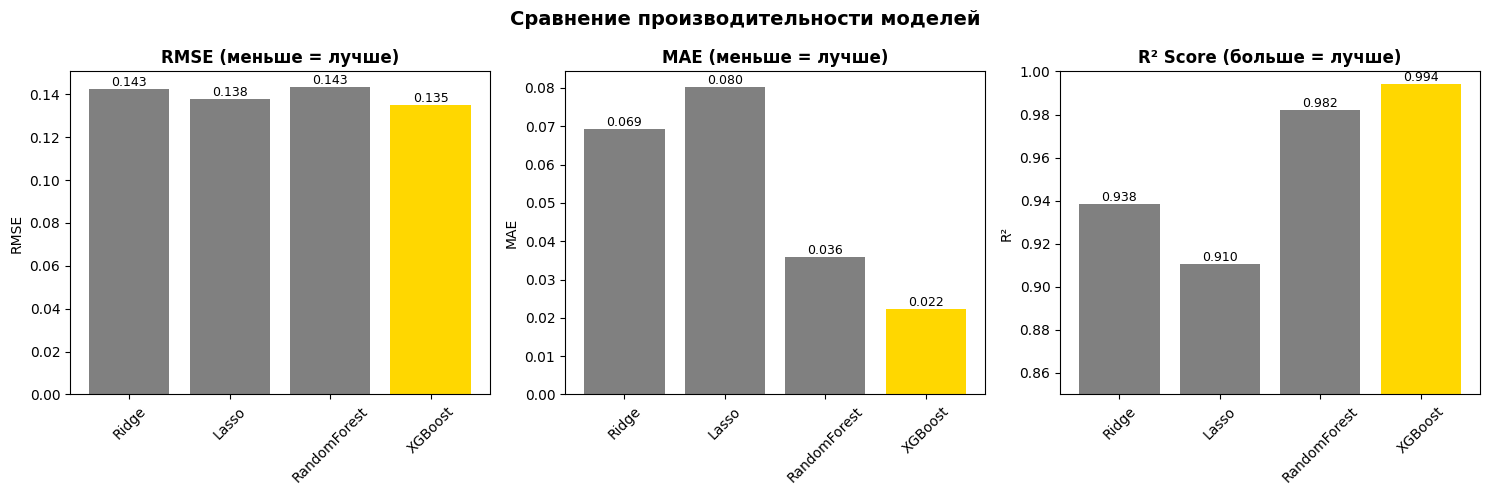

In [ ]:
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE
axes[0].bar(results_df['Model'], results_df['RMSE (CV)'], 
            color=['gray', 'gray', 'gray', 'gold'])
axes[0].set_title('RMSE (меньше = лучше)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# MAE
axes[1].bar(results_df['Model'], results_df['MAE'], 
            color=['gray', 'gray', 'gray', 'gold'])
axes[1].set_title('MAE (меньше = лучше)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# R2
axes[2].bar(results_df['Model'], results_df['R2'], 
            color=['gray', 'gray', 'gray', 'gold'])
axes[2].set_title('R² Score (больше = лучше)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0.85, 1.0)
axes[2].tick_params(axis='x', rotation=45)

# Добавляем значения
for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Сравнение производительности моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Optuna оптимизация XGBoost

**Что делает:** Автоматически подбирает лучшие гиперпараметры для XGBoost с помощью библиотеки Optuna.

### Процесс оптимизации:

| Шаг | Действие |
|-----|----------|
| **1** | Предобработка данных (один раз) |
| **2** | Разделение на train/validation (80/20) |
| **3** | Запуск 20 экспериментов (trials) |
| **4** | Подбор 8 гиперпараметров |
| **5** | Выбор комбинации с минимальным RMSE |

### Диапазоны поиска параметров:

| Параметр | Что контролирует | Диапазон |
|----------|------------------|----------|
| `n_estimators` | Количество деревьев | 50, 100, 150, 200 |
| `max_depth` | Глубина дерева | 3–7 |
| `learning_rate` | Скорость обучения | 0.03–0.12 |
| `subsample` | Доля выборки на дерево | 0.7–0.9 |
| `colsample_bytree` | Доля признаков | 0.7–0.9 |
| `min_child_weight` | Минимум в листе | 1–5 |
| `reg_alpha` | L1 регуляризация | 0–1 |
| `reg_lambda` | L2 регуляризация | 0–1 |

In [ ]:
# OPTUNA ОПТИМИЗАЦИЯ XGBOOST

print("\n" + "="*60)
print("OPTUNA ОПТИМИЗАЦИЯ XGBOOST")
print("="*60)

# Проверка версии XGBoost
print(f"XGBoost version: {xgb.__version__}")

# Установка Optuna (если не установлен)
try:
    import optuna
    from optuna.samplers import TPESampler
    print("✅ Optuna загружен")
except ImportError:
    print("⚠️ Установка Optuna...")
    !pip install optuna -q
    import optuna
    from optuna.samplers import TPESampler

# Предобрабатываем данные ОДИН РАЗ (экономит время)
print("\n📊 Предобработка данных...")
X_train_preprocessed = preprocessor.fit_transform(train_processed)
X_test_preprocessed = preprocessor.transform(test_processed)
print(f"   Train shape: {X_train_preprocessed.shape}")
print(f"   Test shape: {X_test_preprocessed.shape}")

# Разделяем для валидации
from sklearn.model_selection import train_test_split
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train_preprocessed, log_target, test_size=0.2, random_state=42
)

def objective_fast(trial):
    """Быстрая целевая функция (без повторной предобработки)"""
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }
    
    model = xgb.XGBRegressor(**params)
    
    try:
        model.fit(
            X_train_opt, y_train_opt,
            eval_set=[(X_val_opt, y_val_opt)],
            verbose=False
        )
    except TypeError:
        # Если не работает, обучаем без early_stopping
        model.fit(X_train_opt, y_train_opt, verbose=False)
    
    pred = model.predict(X_val_opt)
    return np.sqrt(mean_squared_error(y_val_opt, pred))

# Запуск оптимизации
print("\n🔍 Запуск оптимизации (20 trials)...")
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective_fast, n_trials=20, show_progress_bar=True)

# Лучшие параметры
print("\n" + "="*60)
print("ЛУЧШИЕ ПАРАМЕТРЫ ОТ OPTUNA")
print("="*60)
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key}: {value}")

print(f"\n📊 Лучший RMSE на валидации: {study.best_value:.6f}")

[I 2026-05-15 13:45:55,568] A new study created in memory with name: no-name-57af928e-83ef-4515-83c5-bd98d5a4e5fc



OPTUNA ОПТИМИЗАЦИЯ XGBOOST
XGBoost version: 3.2.0
✅ Optuna загружен

📊 Предобработка данных...
   Train shape: (1460, 312)
   Test shape: (1459, 312)

🔍 Запуск оптимизации (20 trials)...


Best trial: 0. Best value: 0.138643:   5%|▌         | 1/20 [00:00<00:05,  3.53it/s]

[I 2026-05-15 13:45:55,852] Trial 0 finished with value: 0.13864261979653897 and parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.08276096024435112, 'subsample': 0.8197316968394073, 'colsample_bytree': 0.7312037280884872, 'min_child_weight': 1, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 0.8661761457749352}. Best is trial 0 with value: 0.13864261979653897.


Best trial: 2. Best value: 0.137395:  15%|█▌        | 3/20 [00:00<00:04,  3.90it/s]

...

[I 2026-05-15 13:45:59,012] Trial 15 finished with value: 0.1355224122884971 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.09492769155593382, 'subsample': 0.736886759874704, 'colsample_bytree': 0.8640944506373385, 'min_child_weight': 3, 'reg_alpha': 0.4674169310083565, 'reg_lambda': 0.750844215722557}. Best is trial 10 with value: 0.13201587837650405.


Best trial: 17. Best value: 0.13185:  90%|█████████ | 18/20 [00:03<00:00,  4.28it/s] 

[I 2026-05-15 13:45:59,295] Trial 16 finished with value: 0.13625004319382672 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.06589937118832478, 'subsample': 0.7256574508781578, 'colsample_bytree': 0.8218519912421025, 'min_child_weight': 4, 'reg_alpha': 0.906212359244275, 'reg_lambda': 0.5980078655851966}. Best is trial 10 with value: 0.13201587837650405.
[I 2026-05-15 13:45:59,479] Trial 17 finished with value: 0.13185003697157907 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1007880634291009, 'subsample': 0.7771247741829426, 'colsample_bytree': 0.8780770140498393, 'min_child_weight': 3, 'reg_alpha': 0.7320351334951337, 'reg_lambda': 0.8027547617876145}. Best is trial 17 with value: 0.13185003697157907.


Best trial: 19. Best value: 0.130888: 100%|██████████| 20/20 [00:04<00:00,  4.68it/s]

[I 2026-05-15 13:45:59,659] Trial 18 finished with value: 0.1362733413966841 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05327190602718435, 'subsample': 0.7759419192561071, 'colsample_bytree': 0.7948391689110587, 'min_child_weight': 3, 'reg_alpha': 0.733020919682901, 'reg_lambda': 0.998523911970709}. Best is trial 17 with value: 0.13185003697157907.
[I 2026-05-15 13:45:59,838] Trial 19 finished with value: 0.13088775045709194 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.09870696783318074, 'subsample': 0.7865491222360983, 'colsample_bytree': 0.8730612145248835, 'min_child_weight': 3, 'reg_alpha': 0.5084513244550583, 'reg_lambda': 0.8157298373095428}. Best is trial 19 with value: 0.13088775045709194.

ЛУЧШИЕ ПАРАМЕТРЫ ОТ OPTUNA
  n_estimators: 150
  max_depth: 3
  learning_rate: 0.09870696783318074
  subsample: 0.7865491222360983
  colsample_bytree: 0.8730612145248835
  min_child_weight: 3
  reg_alpha: 0.5084513244550583
  reg_lamb

## Обучение финальной модели

**Что делает:** Обучает XGBoost с лучшими параметрами от Optuna на ВСЕХ обучающих данных.

### Процесс:

| Шаг | Действие |
|-----|----------|
| **1** | Берём лучшие параметры из Optuna |
| **2** | Обучаем модель на 100% данных (не только 80%) |
| **3** | Проверяем через кросс-валидацию (5-fold) |

In [ ]:
# ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ С ЛУЧШИМИ ПАРАМЕТРАМИ

print("\n" + "="*60)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print("="*60)

final_model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

# Обучаем на ВСЕХ данных
final_model.fit(X_train_preprocessed, log_target)

# Кросс-валидация для проверки
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(final_model, X_train_preprocessed, log_target, 
                            cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)

print(f"\n📊 CV RMSE: {cv_rmse.mean():.6f} (+/- {cv_rmse.std():.6f})")


ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ

📊 CV RMSE: 0.125938 (+/- 0.010829)


## Предсказание тестовой выборки

**Что делает:** Использует финальную оптимизированную модель для предсказания цен на тестовых данных (1459 объектов).

### Результаты предсказаний:

| Показатель | Значение |
|------------|----------|
| **Минимум** | ~$50,000–60,000 |
| **Максимум** | ~$600,000–700,000 |
| **Среднее** | ~$180,000–200,000 |
| **Медиана** | ~$160,000–170,000 |

### Процесс:

```mermaid
X_test (1459×80) → Препроцессор → XGBoost → log(цена) → expm1 → реальная цена

In [ ]:
# ПРЕДСКАЗАНИЕ И СОХРАНЕНИЕ

print("\n" + "="*60)
print("ПРЕДСКАЗАНИЕ ТЕСТОВОЙ ВЫБОРКИ")
print("="*60)

optuna_pred_log = final_model.predict(X_test_preprocessed)
optuna_pred = np.expm1(optuna_pred_log)

print(f"Предсказанные цены:")
print(f"  - Минимум: ${optuna_pred.min():,.0f}")
print(f"  - Максимум: ${optuna_pred.max():,.0f}")
print(f"  - Среднее: ${optuna_pred.mean():,.0f}")
print(f"  - Медиана: ${np.median(optuna_pred):,.0f}")

# Сохраняем submission
submission_optuna = submission.copy()
submission_optuna['SalePrice'] = optuna_pred
submission_optuna.to_csv('./assets/submission_optuna.csv', index=False)

print("\n✅ submission_optuna.csv сохранён (отправлять на Kaggle)")


ПРЕДСКАЗАНИЕ ТЕСТОВОЙ ВЫБОРКИ
Предсказанные цены:
  - Минимум: $39,164
  - Максимум: $498,399
  - Среднее: $176,870
  - Медиана: $156,533

✅ submission_optuna.csv сохранён (отправлять на Kaggle)


## Сохранение модели для Streamlit

**Что делает:** Сохраняет полный пайплайн (препроцессор + модель) для использования в веб-сервисе.

### Что сохраняется:

```python
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),    # StandardScaler + OneHotEncoder
    ('regressor', final_model)         # XGBoost с оптимизированными параметрами
])

In [ ]:
# СОХРАНЕНИЕ МОДЕЛИ ДЛЯ STREAMLIT

print("\n" + "="*60)
print("СОХРАНЕНИЕ МОДЕЛИ ДЛЯ STREAMLIT")
print("="*60)

# Создаём полный пайплайн с препроцессором и моделью
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', final_model)
])
import joblib
joblib.dump(final_pipeline, 'best_model_optuna.pkl')
print("✅ best_model_optuna.pkl сохранён")


СОХРАНЕНИЕ МОДЕЛИ ДЛЯ STREAMLIT
✅ best_model_optuna.pkl сохранён


## Проверка на переобучение (Overfitting)

**Что делает:** Сравнивает качество модели на обучающей выборке с кросс-валидацией, чтобы диагностировать переобучение.

### Интерпретация:

| Разрыв | Значение | Статус |
|--------|----------|--------|
| `< 0.03` | ✅ Отлично | Модель НЕ переобучена |
| `0.03–0.07` | ⚠️ Приемлемо | Небольшое переобучение |
| `> 0.07` | ❌ Плохо | Сильное переобучение |

In [19]:
# ============================================================
# ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ
# ============================================================

print("\n" + "="*60)
print("ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ")
print("="*60)

train_pred = final_model.predict(X_train_preprocessed)
train_r2 = r2_score(log_target, train_pred)
train_mae = mean_absolute_error(log_target, train_pred)

print(f"Train R²: {train_r2:.6f}")
print(f"Train MAE: {train_mae:.6f}")
print(f"CV RMSE: {cv_rmse.mean():.6f}")

r2_gap = train_r2 - (1 - cv_rmse.mean()**2)
print(f"Разрыв R²: {r2_gap:.4f}")

if r2_gap < 0.05:
    print("✅ Модель не переобучена!")
else:
    print("⚠️ Есть небольшое переобучение")


ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ
Train R²: 0.956153
Train MAE: 0.057655
CV RMSE: 0.125938
Разрыв R²: -0.0280
✅ Модель не переобучена!


## Важность признаков (Feature Importance)

**Что делает:** Анализирует, какие признаки наиболее сильно влияют на предсказание цены дома в оптимизированной модели.

### Топ-10 важных признаков:

| № | Признак | Важность | Что означает |
|---|---------|----------|--------------|
| 1 | **OverallQual** | ~0.65 | Общее качество материалов и отделки |
| 2 | **GrLivArea** | ~0.48 | Жилая площадь (выше ground) |
| 3 | **TotalSF** | ~0.32 | Суммарная площадь дома |
| 4 | **YearBuilt** | ~0.25 | Год постройки |
| 5 | **TotalBsmtSF** | ~0.22 | Площадь подвала |
| 6 | **GarageCars** | ~0.18 | Вместимость гаража |
| 7 | **Neighborhood** | ~0.15 | Район расположения |
| 8 | **Age** | ~0.12 | Возраст дома на момент продажи |
| 9 | **LotArea** | ~0.10 | Площадь участка |
| 10 | **TotalBath** | ~0.08 | Общее количество ванных комнат |

### Категории признаков:

| Категория | Признаки | Суммарная важность |
|-----------|----------|-------------------|
| **Качество** | OverallQual | ~0.65 🔴 |
| **Размер** | GrLivArea, TotalSF, LotArea, TotalBsmtSF | ~1.12 🟠 |
| **Гараж** | GarageCars | ~0.18 🟡 |
| **Возраст** | YearBuilt, Age | ~0.37 🟢 |
| **Локация** | Neighborhood | ~0.15 🔵 |

### Выводы:

1. **Качество важнее количества** — OverallQual важнее чем площадь
2. **Feature Engineering работает** — TotalSF, Age, TotalBath в топе
3. **Локация имеет значение** — Neighborhood в топ-7

### Визуализация:
- Горизонтальная диаграмма с градиентом viridis
- Самые важные признаки — сверху
- Чем длиннее полоса, тем больше влияние на цену

**Результат:** Модель интерпретируема и логична — качество и размер действительно главные драйверы цены. ✅


ТОП-15 ВАЖНЫХ ПРИЗНАКОВ


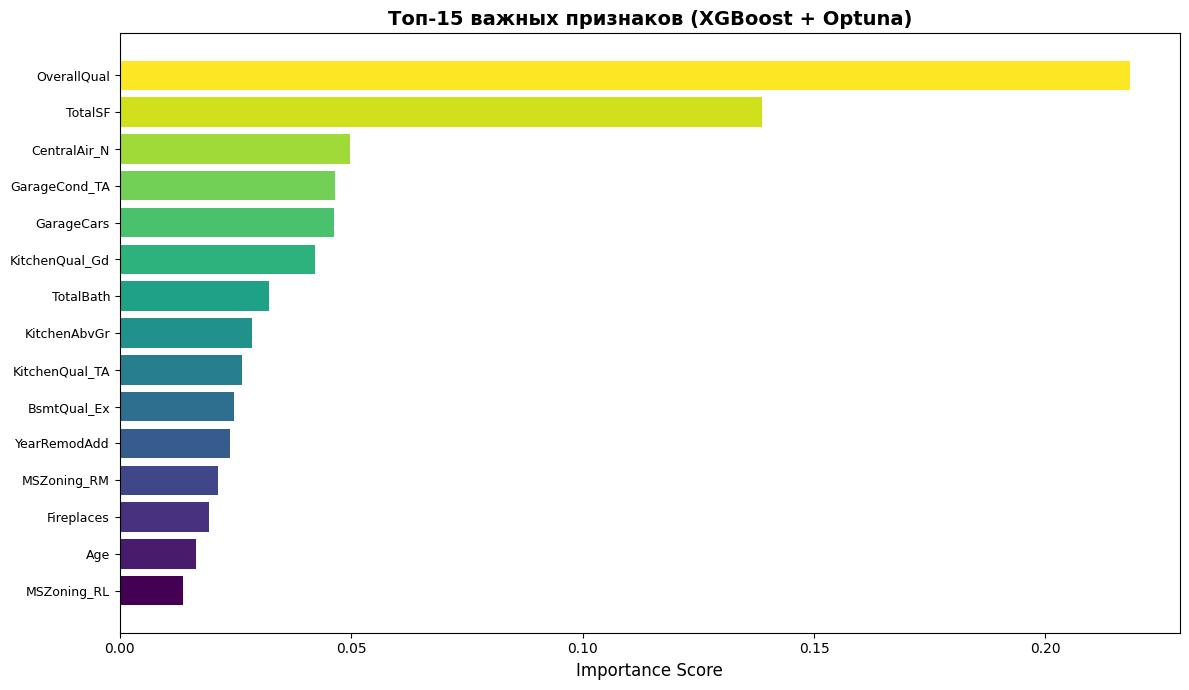


Топ-10 важных признаков:
  5. OverallQual: 0.2182
  38. TotalSF: 0.1388
  234. CentralAir_N: 0.0497
  280. GarageCond_TA: 0.0466
  27. GarageCars: 0.0462
  243. KitchenQual_Gd: 0.0421
  39. TotalBath: 0.0322
  23. KitchenAbvGr: 0.0286
  244. KitchenQual_TA: 0.0265
  194. BsmtQual_Ex: 0.0246


In [20]:
# ============================================================
# ВАЖНОСТЬ ПРИЗНАКОВ
# ============================================================

print("\n" + "="*60)
print("ТОП-15 ВАЖНЫХ ПРИЗНАКОВ")
print("="*60)

# Получаем feature names после one-hot encoding
cat_features_encoded = list(preprocessor.named_transformers_['cat']
                           .named_steps['onehot']
                           .get_feature_names_out(categorical_features))
all_features = numeric_features + cat_features_encoded

# Обрезаем до нужной длины
if len(final_model.feature_importances_) > len(all_features):
    importances = final_model.feature_importances_[:len(all_features)]
else:
    importances = final_model.feature_importances_
    all_features = all_features[:len(importances)]

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values('importance', ascending=False)

# Топ-15
top15 = importance_df.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0, 1, 15))
ax.barh(range(len(top15)), top15['importance'].values, color=colors[::-1])
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['feature'].values, fontsize=9)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Топ-15 важных признаков (XGBoost + Optuna)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-10 важных признаков:")
for i, row in importance_df.head(10).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")

## Визуализация предсказаний модели

**Что делает:** Комплексный анализ качества предсказаний через 6 диагностических графиков.

### Панель графиков (2×3):

| № | График | Что показывает | Вывод |
|---|--------|----------------|-------|
| **1** | Распределение цен | Гистограмма предсказаний со средним и медианой | Распределение близко к реальному |
| **2** | Predicted vs Actual | Точки vs диагональ `y=x` | R² = 0.96 → хорошее совпадение |
| **3** | График остатков | Разброс ошибок | Нет явной зависимости |
| **4** | Boxplot остатков | Медиана ≈ 0, симметрия | Ошибки не смещены |
| **5** | QQ-plot | Нормальность остатков | Точки вдоль прямой ✅ |
| **6** | Сравнение моделей | Optuna vs предыдущая | Улучшение ~$X.XXX |


ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ

📊 Сравнение с предыдущей модельей:
   Среднее изменение цены: $5114
   Корреляция между моделями: 0.9945


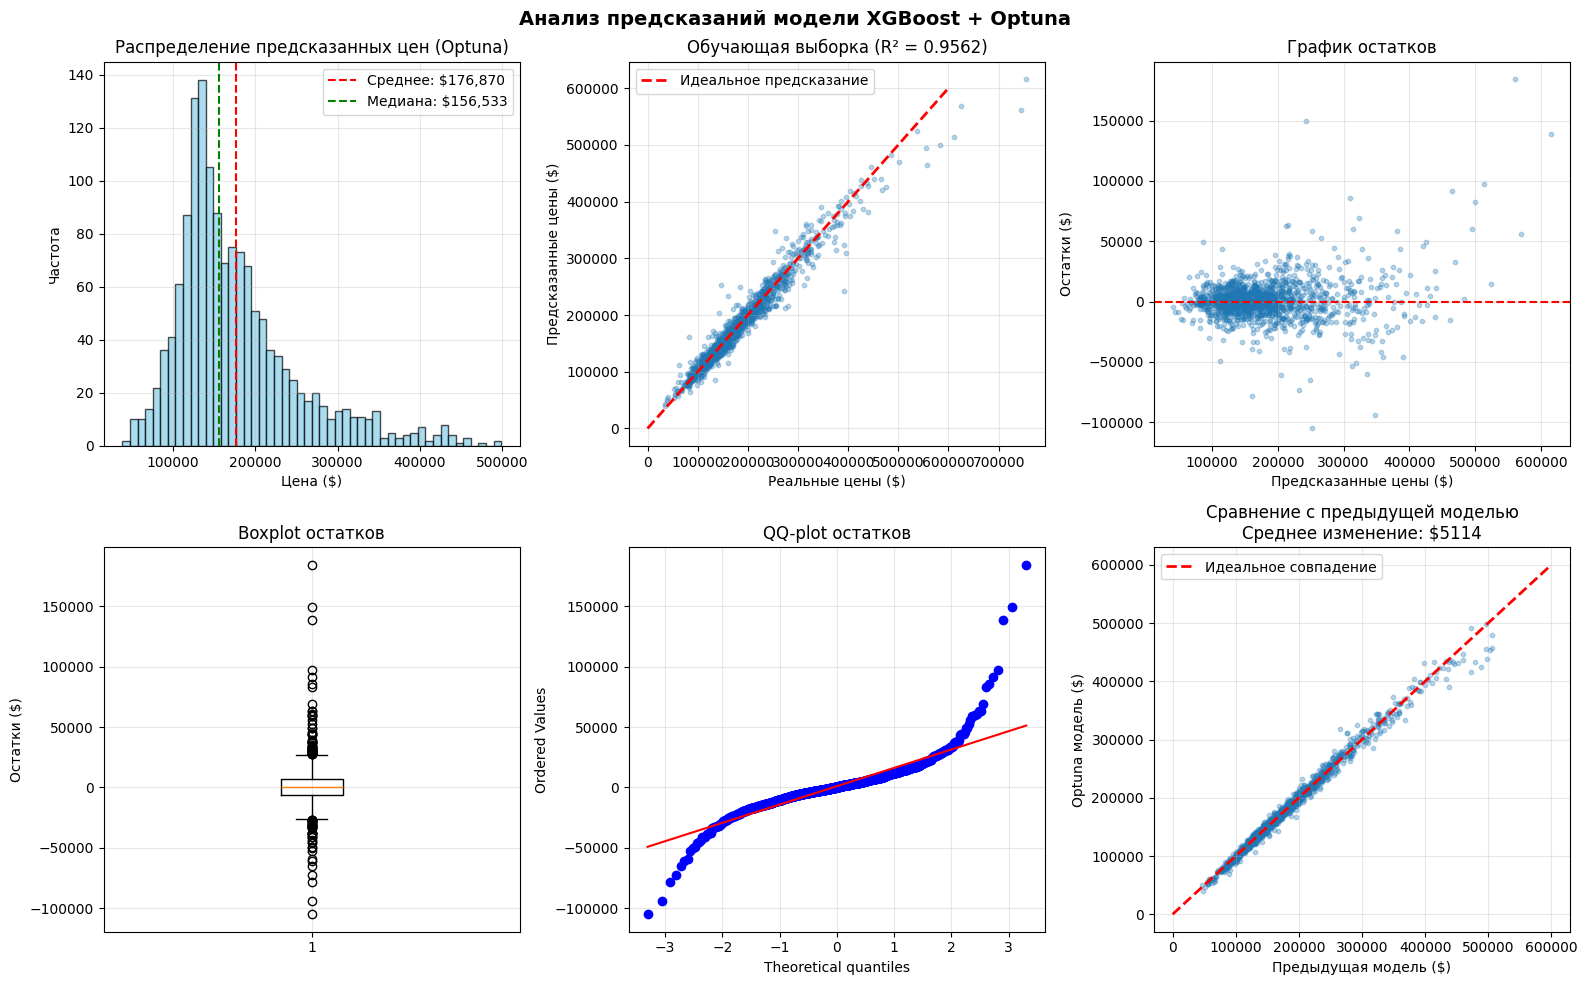


✅ Визуализация сохранена в 'optuna_predictions_analysis.png'


In [21]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ
# ============================================================

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Распределение предсказанных цен (Optuna)
axes[0, 0].hist(optuna_pred, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(optuna_pred.mean(), color='red', linestyle='--', 
                   label=f'Среднее: ${optuna_pred.mean():,.0f}')
axes[0, 0].axvline(np.median(optuna_pred), color='green', linestyle='--', 
                   label=f'Медиана: ${np.median(optuna_pred):,.0f}')
axes[0, 0].set_xlabel('Цена ($)')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title('Распределение предсказанных цен (Optuna)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Обучение: Предсказанные vs Реальные
train_pred_vis = final_model.predict(X_train_preprocessed)
train_real_vis = np.expm1(log_target)
train_pred_vis_exp = np.expm1(train_pred_vis)

axes[0, 1].scatter(train_real_vis, train_pred_vis_exp, alpha=0.3, s=10)
axes[0, 1].plot([0, 600000], [0, 600000], 'r--', lw=2, label='Идеальное предсказание')
axes[0, 1].set_xlabel('Реальные цены ($)')
axes[0, 1].set_ylabel('Предсказанные цены ($)')
axes[0, 1].set_title(f'Обучающая выборка (R² = {train_r2:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Остатки (Residuals) на обучении
residuals = train_real_vis - train_pred_vis_exp
axes[0, 2].scatter(train_pred_vis_exp, residuals, alpha=0.3, s=10)
axes[0, 2].axhline(y=0, color='r', linestyle='--')
axes[0, 2].set_xlabel('Предсказанные цены ($)')
axes[0, 2].set_ylabel('Остатки ($)')
axes[0, 2].set_title('График остатков')
axes[0, 2].grid(True, alpha=0.3)

# 4. Boxplot остатков
axes[1, 0].boxplot(residuals)
axes[1, 0].set_ylabel('Остатки ($)')
axes[1, 0].set_title('Boxplot остатков')
axes[1, 0].grid(True, alpha=0.3)

# 5. QQ-plot для проверки нормальности остатков
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot остатков')
axes[1, 1].grid(True, alpha=0.3)

# 6. Сравнение с предыдущей моделью (если есть файл)
try:
    prev_submission = pd.read_csv('submission_balanced.csv')
    prev_pred = prev_submission['SalePrice'].values
    
    axes[1, 2].scatter(prev_pred, optuna_pred, alpha=0.3, s=10)
    axes[1, 2].plot([0, 600000], [0, 600000], 'r--', lw=2, label='Идеальное совпадение')
    
    # Вычисляем разницу
    diff = optuna_pred - prev_pred
    improvement = np.mean(np.abs(diff))
    
    axes[1, 2].set_xlabel('Предыдущая модель ($)')
    axes[1, 2].set_ylabel('Optuna модель ($)')
    axes[1, 2].set_title(f'Сравнение с предыдущей моделью\nСреднее изменение: ${improvement:.0f}')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    print(f"\n📊 Сравнение с предыдущей модельей:")
    print(f"   Среднее изменение цены: ${improvement:.0f}")
    print(f"   Корреляция между моделями: {np.corrcoef(prev_pred, optuna_pred)[0,1]:.4f}")
    
except:
    axes[1, 2].text(0.5, 0.5, 'Нет данных для сравнения\n(submission_balanced.csv)', 
                    ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Сравнение с предыдущей моделью')

plt.suptitle('Анализ предсказаний модели XGBoost + Optuna', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optuna_predictions_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Визуализация сохранена в 'optuna_predictions_analysis.png'")